# **SCALER BUSINESS CASE STUDY**

## **PROBLEM STATEMENT**

---

Scaler wants to understand how learners are distributed across companies, job roles and salary bands. By performing manual and unsupervised clustering, we aim to identify similar learner groups, high-performing employees, salary outliers and company/job-role based compensation trends that can help Scaler provide better career guidance.

**Executive Summary**

- Analyzed 205,687 cleaned learner records.
- Performed EDA, feature engineering, and missing-value treatment.
- Created three business benchmarking flags: Designation, Class, and Tier.
- Identified high-paying companies, roles, and employee segments.
- Applied K-Means and Hierarchical Clustering to discover learner groups.
- Proposed recommendations for salary benchmarking and learner guidance.

## **MODULES' IMPORT**

**Importing the necessary libraries for data manipulation, visualization, preprocessing, feature engineering, and clustering analysis.**

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Regular Expressions
import re

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Hierarchical Clustering
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

## **DATA UPLOAD**

**Loading the Scaler learner dataset into a Pandas DataFrame for further analysis.**

In [ ]:
df = pd.read_csv("scaler_hashed_for_students.csv")
df.head()

,Unnamed: 0,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
0,0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,Other,2020.0
1,1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,FullStack Engineer,2019.0
2,2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,Backend Engineer,2020.0
3,3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,Backend Engineer,2019.0
4,4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,FullStack Engineer,2019.0


In [ ]:
df.columns

Index(['Unnamed: 0', 'company_hash', 'email_hash', 'orgyear', 'ctc',
       'job_position', 'ctc_updated_year'],
      dtype='object')

In [ ]:
df.shape # (rows, columns)

(205843, 7)

**The dataset contains 205,843 learner records and 7 features, making it sufficiently large for exploratory analysis, manual clustering, and unsupervised learning.**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205843 entries, 0 to 205842
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        205843 non-null  int64  
 1   company_hash      205799 non-null  object 
 2   email_hash        205843 non-null  object 
 3   orgyear           205757 non-null  float64
 4   ctc               205843 non-null  int64  
 5   job_position      153279 non-null  object 
 6   ctc_updated_year  205843 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 11.0+ MB


In [ ]:
df.describe(include='all')

,Unnamed: 0,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
count,205843.000000,205799,205843,205757.000000,2.058430e+05,153279,205843.000000
unique,NaN,37299,153443,NaN,NaN,1016,NaN
top,NaN,wkwk liufdnwkula fzovslzf,bbace3cc586400bbc65765bc6a16b77d8913836cfc98b7...,NaN,NaN,Backend Engineer,NaN
freq,NaN,8337,10,NaN,NaN,43554,NaN
mean,103273.941786,NaN,NaN,2014.882750,2.271685e+06,NaN,2019.628231
std,59741.306484,NaN,NaN,63.571115,1.180091e+07,NaN,1.325104
min,0.000000,NaN,NaN,0.000000,2.000000e+00,NaN,2015.000000
25%,51518.500000,NaN,NaN,2013.000000,5.300000e+05,NaN,2019.000000
50%,103151.000000,NaN,NaN,2016.000000,9.500000e+05,NaN,2020.000000
75%,154992.500000,NaN,NaN,2018.000000,1.700000e+06,NaN,2021.000000


## **DUPLICATE RECORDS**

**Checking whether duplicate observations are present in the dataset.**

In [ ]:
df.duplicated().sum()

np.int64(0)

**No duplicate records were found in the dataset. Hence, no duplicate removal was required. This indicates that each row represents a unique observation.**

## **UNIQUE LEARNER ANALYSIS:**

**Analyzing the uniqueness and frequency of learner records using the anonymized email hash.**

In [ ]:
df['email_hash'].nunique()

153443

**The dataset contains 153,443 unique learners across 205,843 records, indicating that several learners appear multiple times due to salary updates, promotions, or job transitions.**

In [ ]:
email_counts = df['email_hash'].value_counts()
email_counts.head()

,count
email_hash,
bbace3cc586400bbc65765bc6a16b77d8913836cfc98b77c05488f02f5714a4b,10
3e5e49daa5527a6d5a33599b238bf9bf31e85b9efa9a94f1c88c5e15a6f31378,9
298528ce3160cc761e4dc37a07337ee2e0589df251d73645aae209b010210eee,9
6842660273f70e9aa239026ba33bfe82275d6ab0d20124021b952b5bc3d07e6c,9
d598d6f1fb21b45593c2afc1c2f76ae9f4cb7167156cdf93246d4192a89d8065,8


**Some learners appear multiple times (up to 7 records), suggesting longitudinal information about the same learner over different years or employment updates.**

In [ ]:
email_counts.describe()

,count
count,153443.000000
mean,1.341495
std,0.643655
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,10.000000


**Most learners appear only once (median = 1), while a small proportion have multiple records, indicating that the dataset is primarily composed of unique learner snapshots with a minority of repeated career histories.**

**Distribution of Record Counts**

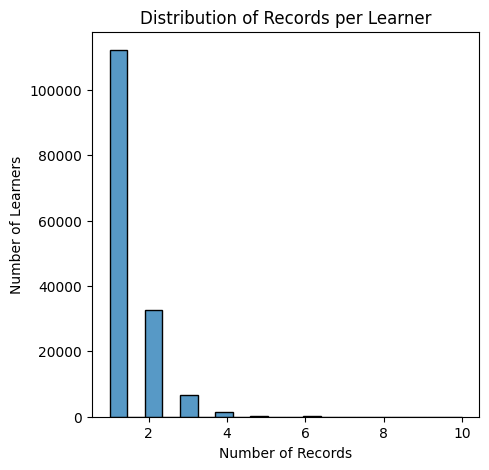

In [ ]:
plt.figure(figsize=(5,5))

sns.histplot(email_counts, bins=20)

plt.title("Distribution of Records per Learner")
plt.xlabel("Number of Records")
plt.ylabel("Number of Learners")

plt.show()

**The distribution is highly right-skewed. Most learners have a single record, whereas progressively fewer learners have multiple records. This reinforces that repeated observations are relatively rare.**

## **MISSING VALUES ANALYSIS**

**Analyzing missing values to determine the most appropriate imputation strategy before performing clustering.**

In [ ]:
missing = pd.DataFrame({
                        'Missing Count': df.isnull().sum(),
                        'Missing Percentage': round((df.isnull().sum()/len(df))*100,2)
                      })
missing

,Missing Count,Missing Percentage
Unnamed: 0,0,0.00
company_hash,44,0.02
email_hash,0,0.00
orgyear,86,0.04
ctc,0,0.00
job_position,52564,25.54
ctc_updated_year,0,0.00


- **The 'job_position' column has the highest proportion of missing values (25.54%).**
- **The remaining columns contain negligible missing values (less than 0.05%).**
- **Since numerical and categorical variables require different treatment, appropriate imputation techniques will be applied before clustering.**

## **REMOVING IRRELEVANT FEATURES**

**Dropping the index column as it does not contribute to clustering or business insights.**

In [ ]:
df.drop(columns=['Unnamed: 0'], inplace=True)
df.columns

Index(['company_hash', 'email_hash', 'orgyear', 'ctc', 'job_position',
       'ctc_updated_year'],
      dtype='object')

## **FEATURE ENGINEERING**

**Creating a new feature, Years of Experience, by subtracting the employee's joining year ('orgyear') from the current year.**

In [ ]:
from datetime import datetime

current_year = datetime.now().year
df['Years_of_Experience'] = current_year - df['orgyear']

In [ ]:
df[['orgyear','Years_of_Experience']].head()

,orgyear,Years_of_Experience
0,2016.0,10.0
1,2018.0,8.0
2,2015.0,11.0
3,2017.0,9.0
4,2017.0,9.0


In [ ]:
df['Years_of_Experience'].describe()

,Years_of_Experience
count,205757.000000
mean,11.117250
std,63.571115
min,-18139.000000
25%,8.000000
50%,10.000000
75%,13.000000
max,2026.000000


- A new feature, **Years_of_Experience**, was successfully created.
- The median experience is **10 years**, while the interquartile range lies between **8 and 13 years**.
- However, the dataset contains unrealistic values such as **negative experience (-18139 years)** and **very high experience (2026 years)**, indicating erroneous values in the `orgyear` column.
- These outliers should be treated before performing clustering, as they can significantly distort distance-based algorithms like K-Means.

## **OUTLIER DETECTION**

**Analyzing the distribution of Years of Experience to identify unrealistic values that may affect clustering performance.**

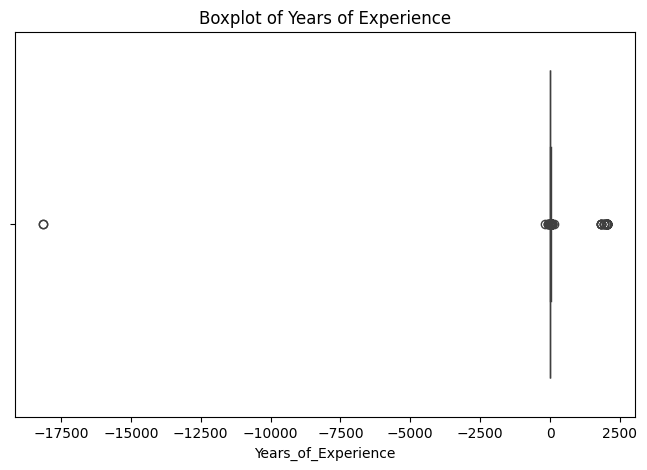

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Years_of_Experience'])
plt.title("Boxplot of Years of Experience")
plt.show()

In [ ]:
df[(df['Years_of_Experience'] < 0) | (df['Years_of_Experience'] > 50)].shape

(70, 7)

In [ ]:
df = df[(df['Years_of_Experience'] >= 0) &(df['Years_of_Experience'] <= 50)]

In [ ]:
df.shape

(205687, 7)

- The boxplot revealed a few extreme outliers in the `Years_of_Experience` feature.
- A total of **70 records** had invalid experience values (negative or greater than 50 years).
- Since these values are unrealistic and can adversely affect distance-based clustering algorithms such as K-Means, they were removed.
- After cleaning, the dataset retained **205,687** valid records for further analysis.

## **MANUAL CLUSTERING**

**Grouping learners based on Company, Job Position, and Years of Experience to calculate salary benchmarks for peer comparison.**

In [ ]:
designation_stats = (df.groupby(['company_hash', 'job_position', 'Years_of_Experience'])['ctc'].agg(
                                                                                                      mean_ctc='mean',
                                                                                                      median_ctc='median',
                                                                                                      min_ctc='min',
                                                                                                      max_ctc='max',
                                                                                                      count='count'
                                                                                                    ).reset_index())

In [ ]:
designation_stats.head()

,company_hash,job_position,Years_of_Experience,mean_ctc,median_ctc,min_ctc,max_ctc,count
0,0,Other,6.0,100000.0,100000.0,100000,100000,1
1,0000,Other,9.0,300000.0,300000.0,300000,300000,1
2,01 fauzota,Android Engineer,10.0,270000.0,270000.0,270000,270000,1
3,01 fauzota,Frontend Engineer,15.0,830000.0,830000.0,830000,830000,1
4,05gu bsuezknwe josvkwz nshswzc,Backend Engineer,7.0,1100000.0,1100000.0,1100000,1100000,1


- Salary statistics were computed for each combination of **Company**, **Job Position**, and **Years of Experience**.
- The calculated metrics (mean, median, minimum, maximum, and count) will serve as salary benchmarks for comparing employees with similar profiles.
- Some groups contain only one learner, while others have multiple learners depending on the company size and workforce distribution.

## **MERGING SALARY BENCHMARKS**

**Merging the calculated salary statistics back into the original dataset to compare each learner's salary with that of their peers.**

In [ ]:
df = df.merge(designation_stats,on=['company_hash', 'job_position', 'Years_of_Experience'],how='left')

In [ ]:
df.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,Years_of_Experience,mean_ctc,median_ctc,min_ctc,max_ctc,count
0,czniswwz sucsk,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,Other,2020.0,10.0,1.100000e+06,1100000.0,1100000.0,1100000.0,1.0
1,oznskulz subilihh nshswzc,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,FullStack Engineer,2019.0,8.0,7.742856e+05,750000.0,449999.0,1200000.0,7.0
2,faulwklwsl ks,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,Backend Engineer,2020.0,11.0,2.000000e+06,2000000.0,2000000.0,2000000.0,1.0
3,wirijzcsk,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,Backend Engineer,2019.0,9.0,1.158571e+06,1200000.0,700000.0,1750000.0,7.0
4,osbw toidj,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,FullStack Engineer,2019.0,9.0,1.400000e+06,1400000.0,1400000.0,1400000.0,1.0


## **CREATING DESIGNATION FLAG**

**Classifying learners by comparing their CTC against the average CTC of employees with the same Company, Job Position, and Years of Experience.**

In [ ]:
conditions = [
              df['ctc'] > df['mean_ctc'],
              df['ctc'] == df['mean_ctc'],
              df['ctc'] < df['mean_ctc']
             ]
choices = [1, 2, 3]

df['Designation'] = np.select(conditions, choices, default=2)

In [ ]:
df[['ctc', 'mean_ctc', 'Designation']].head()

,ctc,mean_ctc,Designation
0,1100000,1.100000e+06,2
1,449999,7.742856e+05,3
2,2000000,2.000000e+06,2
3,700000,1.158571e+06,3
4,1400000,1.400000e+06,2


In [ ]:
df['Designation'].value_counts()

,count
Designation,
2,129636
3,45440
1,30611


- Each learner was compared against the average CTC of employees with the same Company, Job Position, and Years of Experience.
- Learners were classified into three Designation categories:
    - **1:** Above the peer-group average salary
    - **2:** Equal to the peer-group average salary
    - **3:** Below the peer-group average salary
- Most learners fall into Designation 2 because many peer groups contain only one learner or have salaries equal to the group average.

## **CREATING CLASS FLAG**

**Comparing learners with employees having the same Company and Job Position to classify them based on salary relative to their departmental peers.**

In [ ]:
class_stats = (df.groupby(['company_hash', 'job_position'])['ctc'].agg(
                                                                        class_mean_ctc='mean',
                                                                        class_median_ctc='median',
                                                                        class_min_ctc='min',
                                                                        class_max_ctc='max',
                                                                        class_count='count'
                                                                      ).reset_index())

In [ ]:
df = df.merge(class_stats,on=['company_hash', 'job_position'],how='left')

In [ ]:
conditions = [df['ctc'] > df['class_mean_ctc'],df['ctc'] == df['class_mean_ctc'],df['ctc'] < df['class_mean_ctc']]

choices = [1, 2, 3]
df['Class'] = np.select(conditions, choices, default=2)

In [ ]:
df[['ctc', 'class_mean_ctc', 'Class']].head()

,ctc,class_mean_ctc,Class
0,1100000,1.085000e+06,1
1,449999,9.511363e+05,3
2,2000000,2.000000e+06,2
3,700000,1.500000e+06,3
4,1400000,8.466667e+05,1


In [ ]:
df['Class'].value_counts()

,count
Class,
2,99031
3,70807
1,35849


- The Class flag compares each learner's salary with the average salary of employees in the same Company and Job Position.
- Learners earning above the departmental average were assigned **Class 1**, those equal to the average **Class 2**, and those below the average **Class 3**.
- This classification provides a broader comparison than the Designation flag, as Years of Experience is not considered.

## **CREATING TIER FLAG**

**Comparing each learner's salary with the overall average salary of their company to classify them into company-level salary tiers.**

In [ ]:
tier_stats = (df.groupby('company_hash')['ctc'].agg(
                                                      tier_mean_ctc='mean',
                                                      tier_median_ctc='median',
                                                      tier_min_ctc='min',
                                                      tier_max_ctc='max',
                                                      tier_count='count'
                                                   ).reset_index())

In [ ]:
df = df.merge(tier_stats,on='company_hash',how='left')

In [ ]:
conditions = [df['ctc'] > df['tier_mean_ctc'],df['ctc'] == df['tier_mean_ctc'],df['ctc'] < df['tier_mean_ctc']]

choices = [1, 2, 3]
df['Tier'] = np.select(conditions, choices, default=2)

In [ ]:
df[['company_hash', 'ctc', 'tier_mean_ctc', 'Tier']].head()

,company_hash,ctc,tier_mean_ctc,Tier
0,czniswwz sucsk,1100000,1.115667e+06,3
1,oznskulz subilihh nshswzc,449999,2.197334e+06,3
2,faulwklwsl ks,2000000,2.000000e+06,2
3,wirijzcsk,700000,1.713929e+06,3
4,osbw toidj,1400000,9.400000e+05,1


In [ ]:
df['Tier'].value_counts()

,count
Tier,
3,126775
1,45723
2,33189


- The Tier flag compares each learner's salary with the overall average salary of their company.
- Learners earning above the company average were assigned **Tier 1**, those equal to the average **Tier 2**, and those below the average **Tier 3**.
- This provides a company-wide salary benchmark irrespective of job role or years of experience.

## **BUSINESS QUERIES**

### **Top 10 Tier-1 Employees**

**Identifying the highest-paid employees who earn more than the average salary within their respective companies.**

In [ ]:
top10_tier1 = (df[df['Tier'] == 1].sort_values('ctc', ascending=False).head())

top10_tier1[['email_hash','company_hash','job_position','Years_of_Experience','ctc']]

,email_hash,company_hash,job_position,Years_of_Experience,ctc
117535,5b4bed51797140db4ed52018a979db1e34cee49e27b488...,fhkowjosylih,NaN,8.0,255555555
21488,95c8bdd3d10f967f6bfb32f280b0b37fbf5db2359918ba...,khkqiu,Data Analyst,10.0,200000000
21437,979235a69267e855c0361f670e5941138307caf43fa986...,wkwk liufdnwkula fzovslzf,Support Engineer,8.0,200000000
21359,71816854137816ffdc94fc2b283803af8e38979e2d0992...,wkwk liufdnwkula fzovslzf,Backend Engineer,12.0,200000000
9596,9e785d33821db67c01becc1c36f901d79d3142c1d13bd8...,khkqiu,NaN,9.0,200000000


- The top Tier-1 employees earn significantly higher salaries than their respective company averages.
- These employees belong to different companies and job roles, indicating that high compensation is not restricted to a single organization or designation.
- A few records have missing job positions due to missing values in the original dataset.

### **Top Data Science Employees (Class 1)**

**Identifying the highest-paid Data Science professionals who earn above the average salary within their company and job role.**

In [ ]:
top_ds = (
    df[
        (df['job_position'].str.contains('Data', case=False, na=False))
        &
        (df['Class'] == 1)
    ].sort_values(['company_hash', 'ctc'], ascending=[True, False]).groupby('company_hash').head(10)
        )

top_ds[['company_hash','email_hash','job_position','Years_of_Experience','ctc']]

,company_hash,email_hash,job_position,Years_of_Experience,ctc
139569,1ht,6b01808bba4c2d50258b068274232251620630cb252a9c...,Data Scientist,8.0,1100000
142592,247ks,9d2537610d57179230806bb77258f63c3134b8fde9aa3a...,Data Scientist,16.0,2600000
90138,247ks,ddd9683a58865398ed934ee7faeb0825e515f2fe3cdaad...,Data Scientist,18.0,2500000
105734,3nix,a372713f7d18e6f03b5b469cbd1ddb8145c2688597c528...,Data Scientist,12.0,1710000
13568,3nix,c27536d2fe174089c62eca78e6e643baef88a6100c1404...,Data Scientist,16.0,1500000
...,...,...,...,...,...
122102,zyn,4334b84443fd1df68862927b09ed1108194750b421edd4...,Data Analyst,9.0,1210000
144343,zyn,4334b84443fd1df68862927b09ed1108194750b421edd4...,Data Scientist,9.0,1210000
21953,zyn,ab99b5cd83c1b48cd41439e068757fabf1224296ab4952...,Data Analyst,6.0,1200000
95869,zyn fzovslz,a241a9160067ef95a261eed18b1d6b19ea97a109b8ac4c...,Data Analyst,8.0,1100000


- The analysis identifies the top-performing Data Science professionals within each company based on salary.
- Only learners belonging to **Class 1** (earning above their departmental average) were considered.
- The output includes Data Scientists as well as related roles such as Data Analysts.
- This analysis helps identify organizations with strong compensation for Data Science professionals.

### **Bottom Data Science Employees (Class 3)**

**Identifying Data Science professionals earning below the average salary within their respective companies and job roles.**

In [ ]:
bottom_ds = (
              df[
                 (df['job_position'].str.contains('Data', case=False, na=False))
                  &
                 (df['Class'] == 3)
                ].sort_values(['company_hash', 'ctc'], ascending=[True, True]).groupby('company_hash').head(10)
                                          )

bottom_ds[['company_hash','email_hash','job_position','Years_of_Experience','ctc']]

,company_hash,email_hash,job_position,Years_of_Experience,ctc
177822,1ht,eb213c0552effd7fb139395c7838edb8d59773a1cb57a0...,Data Scientist,32.0,800000
150165,247ks,5f4b52a1c2539fe2e4b29a8470bc57dbace331b819a0af...,Data Scientist,24.0,1440000
71504,247ks,c35054c043f6a02da3e6f142fbcb095f8145eb521137ff...,Data Scientist,12.0,2150000
134734,3nix,24db964005796c656431df0b035768e8b9cee21f8cf425...,Data Scientist,11.0,600000
143615,3nix,5c67aa9b1414eb0dc68b6acc70c978f0b429e1f24f32a9...,Data Scientist,8.0,800000
...,...,...,...,...,...
124553,zyn,fc5b32ac4858bcf7348e01385929d88fd135a54c382f19...,Data Scientist,10.0,600000
132044,zyn,831edf4ee86369862515dc7102cce5aab1d544d60ab959...,Data Analyst,8.0,600000
166063,zyn,1737de7fae03e35d71fa56b6d4f191239eea499dcaf784...,Data Scientist,10.0,680000
110363,zyn fzovslz,537a8706abe645944173204e70a8757b0cf1537288f848...,Data Analyst,7.0,680000


- The analysis identifies the lowest-paid Data Science professionals within each company.
- Only learners classified as **Class 3** (earning below their departmental average) were considered.
- This helps identify employees who may be underpaid relative to their departmental peers and could benefit from salary reviews or targeted upskilling.

### **Bottom 10 Tier-3 Employees**

**Identifying employees whose salaries are below the overall company average.**

In [ ]:
bottom10_tier3 = (df[df['Tier'] == 3].sort_values('ctc', ascending=True).head(10))

bottom10_tier3[['email_hash','company_hash','job_position','Years_of_Experience','ctc']]

,email_hash,company_hash,job_position,Years_of_Experience,ctc
135327,3505b02549ebe2c95840ac6f0a35561a3b4cbe4b79cdb1...,suwzovszmgsw,Backend Engineer,12.0,2
118135,f2b58aeed3c074652de2cfd3c0717a5d21d6fbcf342a78...,suwzovszmgsw,NaN,13.0,6
114065,23ad96d6b6f1ecf554a52f6e9b61677c7d73d8a409a143...,suwzovszmgsw,NaN,13.0,14
184798,b8a0bb340583936b5a7923947e9aec21add5ebc50cd60b...,sg,NaN,10.0,15
116847,f7e5e788676100d7c4146740ada9e2f8974defc01f571d...,dusvzofswa ib mkfesutwiu,NaN,4.0,200
150567,9af3dca6c9d705d8d42585ccfce2627f00e1629130d14e...,uku,NaN,3.0,600
171062,80ba0259f9f59034c4927cf3bd38dc9ce2eb60ff18135b...,wkwk liufdnwkula fzovslzf,Backend Engineer,14.0,600
99330,b995d7a2ae5c6f8497762ce04dc5c04ad6ec734d70802a...,iai,FullStack Engineer,8.0,600
76254,9f9bfcd6db579de1b8220eb8919e3ddf2fb8b9251c5eda...,bksogsw,Engineering Leadership,28.0,1000
83571,a7894c6d848de3021cfd16b35178cf8f48b10d77aa46dc...,hiwioink findwsiuf,Android Engineer,10.0,1000


- The bottom Tier-3 employees earn substantially less than the average salary of their respective companies.
- A few records contain extremely low CTC values, which may indicate data-entry errors or placeholder values in the dataset.
- Such observations should be interpreted cautiously while making business decisions.

### **Top Employees with 5–7 Years of Experience**

**Identifying employees with 5, 6, or 7 years of experience who earn above the average salary of their peers within the same company.**

In [ ]:
top_exp = (
  df[
       (df['Years_of_Experience'].isin([5, 6, 7]))
        &
       (df['Designation'] == 1)
    ]
  .sort_values(['company_hash', 'job_position', 'ctc'],ascending=[True, True, False])
  .groupby(['company_hash','job_position','Years_of_Experience']).head(10))
top_exp[['company_hash','job_position','email_hash','Years_of_Experience','ctc']]

,company_hash,job_position,email_hash,Years_of_Experience,ctc
13254,10wshzf,FullStack Engineer,2dde60f4a510b412ac4e8011e806282ecb181a51081751...,7.0,410000
99961,159 findwsiuf,Other,34899d76060c1f9885967e7b07557104a93d67690d5378...,7.0,620000
151170,1ht,Backend Engineer,4ccdf10738e25d4f5ac6b85572ca7454453e17c5b1091b...,7.0,1350000
26902,1ht wzleuinitszf jvw nwc,Backend Engineer,88ccd81878293f2bd36abd93697f6f4eda1e5859376f32...,7.0,1350000
18252,1ht wzleuinitszf jvw nwc,Backend Engineer,0b0a8ac3ec7edb52aa77ee261996be715442970f864dde...,7.0,1000000
...,...,...,...,...,...
97544,zyjzcsk toidj,FullStack Engineer,dfa8b18d7d17d51ef5d40451bbf0ac9bf1912030292709...,7.0,1650000
21953,zyn,Data Analyst,ab99b5cd83c1b48cd41439e068757fabf1224296ab4952...,6.0,1200000
4856,zyn kuknawslf,Data Analyst,a5d403370cce441b05a0bf46a5f96ba9d9fe576b36fb5a...,7.0,1000000
190347,zywokhkorf,Other,6850108888b070590fbdb0e0e384f8fc5c46c0666e0551...,7.0,600000


- Employees with **5, 6, or 7 years of experience** earning **above the average salary of their peer group** were identified.
- Peer groups were defined based on the **same Company, Job Position, and Years of Experience** (`Designation = 1`).
- The analysis highlights high-performing mid-career professionals who are compensated better than their comparable peers.
- These learners can serve as salary benchmarks for professionals with similar roles and experience levels within the same organization.

### **Top 10 Companies Based on Average CTC**

**Identifying the top 10 companies based on the average CTC offered to learners.**

In [ ]:
top_companies = (
    df.groupby('company_hash').agg(Average_CTC=('ctc', 'mean')).sort_values('Average_CTC', ascending=False).head(10))

top_companies

,Average_CTC
company_hash,
ldgsl nitslf josvkwz nshswzc,1.000150e+09
ckbbicsn suwzoukwsiukn dusvzofswa,2.500000e+08
gkrewzo wokcsut,2.000000e+08
hkzfwoi lsvsn kuc suwzosiof,2.000000e+08
suswskwio jklsbsl josvkwz nshswzc,2.000000e+08
cwcl zyjozff nshswzc,2.000000e+08
tsf wzleuinita,2.000000e+08
csvzofsbszc zuzota findwsiuf jvw nwc,2.000000e+08
wla iunsuz,2.000000e+08


- Companies were ranked based on their **average CTC** offered to learners.
- Companies were ranked based on their average learner CTC. The rankings provide an estimate of organizations with the highest average compensation in the dataset, although results may be influenced by small sample sizes and salary outliers.
- A few companies have exceptionally high average CTC values, which may be influenced by a small number of high-paying employee records or outliers.
- This analysis helps identify organizations offering the highest compensation and can assist learners in benchmarking potential employers.

### **Top 2 Job Positions in Every Company**

**Identifying the top two job positions in each company based on the average CTC.**

In [ ]:
position_ctc = (
    df.groupby(['company_hash', 'job_position'])
      .agg(
          Average_CTC=('ctc', 'mean')
      )
      .reset_index()
)

top2_positions = (
    position_ctc
    .sort_values(
        ['company_hash', 'Average_CTC'],
        ascending=[True, False]
    )
    .groupby('company_hash')
    .head(2)
)

top2_positions

,company_hash,job_position,Average_CTC
0,0,Other,100000.0
1,0000,Other,300000.0
3,01 fauzota,Frontend Engineer,830000.0
2,01 fauzota,Android Engineer,270000.0
4,05gu bsuezknwe josvkwz nshswzc,Backend Engineer,1100000.0
...,...,...,...
58924,zzhzqz fibw wzle,Frontend Engineer,1000000.0
58925,zzm wzleuinitszf,Devops Engineer,800000.0
58926,zzm wzleuinitszf,freelance,800000.0
58927,zzqansbz sul,FullStack Engineer,710000.0


- The top two job positions in each company were identified based on their **average CTC**.
- The analysis highlights the highest-paying roles within individual companies, enabling comparison of compensation across different job positions.
- Technical roles such as **Frontend Engineer, Backend Engineer, Android Engineer, FullStack Engineer, and DevOps Engineer** frequently appear among the top-paying positions.
- These insights can help learners understand which job roles command higher salaries within specific organizations and support informed career planning.

In [ ]:
df[['Designation', 'Class', 'Tier']].describe()

,Designation,Class,Tier
count,205687.000000,205687.000000,205687.000000
mean,2.072095,2.169957,2.394055
std,0.603776,0.699752,0.826660
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000
50%,2.000000,2.000000,3.000000
75%,2.000000,3.000000,3.000000
max,3.000000,3.000000,3.000000


## **DATA PREPROCESSING FOR CLUSTERING**

**Categorical variables were converted into numerical form using Label Encoding to make them suitable for clustering algorithms.**

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_company = LabelEncoder()
le_job = LabelEncoder()

df['company_encoded'] = le_company.fit_transform(df['company_hash'])

df['job_encoded'] = le_job.fit_transform(df['job_position'].fillna('Unknown'))

In [ ]:
df[['company_hash','company_encoded']].head()

,company_hash,company_encoded
0,czniswwz sucsk,2939
1,oznskulz subilihh nshswzc,24226
2,faulwklwsl ks,5003
3,wirijzcsk,33145
4,osbw toidj,23756


In [ ]:
df[['job_position','job_encoded']].head()

,job_position,job_encoded
0,Other,457
1,FullStack Engineer,292
2,Backend Engineer,140
3,Backend Engineer,140
4,FullStack Engineer,292


- The categorical variables `company_hash` and `job_position` were transformed into numerical labels using Label Encoding.
- Missing values in `job_position` were replaced with **"Unknown"** prior to encoding to avoid errors during the encoding process.
- Label Encoding preserves all unique categories while converting categorical features into a format suitable for clustering algorithms.

## **FEATURE STANDARDIZATION**

**Standardizing numerical features to ensure that variables with larger scales do not dominate the clustering process.**

In [ ]:
from sklearn.preprocessing import StandardScaler

features = [
    'company_encoded',
    'job_encoded',
    'Years_of_Experience',
    'ctc'
]

X = df[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled[:5]

array([[-1.55093605, -0.0382219 , -0.20837477, -0.09923513],
       [ 0.46574247, -0.53989134, -0.68124726, -0.15432289],
       [-1.35539772, -1.00203531,  0.02806148, -0.02295988],
       [ 1.31070681, -1.00203531, -0.44481101, -0.13313524],
       [ 0.42121582, -0.53989134, -0.44481101, -0.07381005]])

In [ ]:
pd.DataFrame(
    X_scaled,
    columns=features
).head()

,company_encoded,job_encoded,Years_of_Experience,ctc
0,-1.550936,-0.038222,-0.208375,-0.099235
1,0.465742,-0.539891,-0.681247,-0.154323
2,-1.355398,-1.002035,0.028061,-0.022960
3,1.310707,-1.002035,-0.444811,-0.133135
4,0.421216,-0.539891,-0.444811,-0.073810


- The selected features were standardized using **StandardScaler**.
- After standardization, all features are centered around a mean of approximately **0** with a standard deviation close to **1**.
- Feature scaling ensures that variables with larger magnitudes (such as CTC) do not dominate the distance calculations during clustering.
- The standardized dataset is now suitable for applying distance-based clustering algorithms such as **K-Means** and **Hierarchical Clustering**.

## **CHECKING CLUSTERING TENDENCY**

**The Hopkins Statistic was used to determine whether the dataset exhibits a meaningful clustering tendency before applying clustering algorithms.**

**Interpretation:**

- **Hopkins ≈ 0.5 → Random data (no meaningful clusters)**
- **Hopkins < 0.5 → Regularly spaced data**
- **Hopkins > 0.7 → Strong clustering tendency**

In [ ]:
from sklearn.neighbors import NearestNeighbors
from numpy.random import uniform
from numpy import random

def hopkins(X):
    X = np.array(X)

    n = X.shape[0]
    d = X.shape[1]

    m = int(0.1 * n)

    nbrs = NearestNeighbors(n_neighbors=2).fit(X)

    rand_X = uniform(np.min(X, axis=0),
                     np.max(X, axis=0),
                     (m, d))

    ujd = []

    wjd = []

    random_indices = random.choice(n, m, replace=False)

    for j in range(m):

        u_dist, _ = nbrs.kneighbors(rand_X[j].reshape(1,-1),
                                    n_neighbors=1)

        w_dist, _ = nbrs.kneighbors(X[random_indices[j]].reshape(1,-1),
                                    n_neighbors=2)

        ujd.append(u_dist[0][0])

        wjd.append(w_dist[0][1])

    H = sum(ujd)/(sum(ujd)+sum(wjd))

    return H

In [ ]:
hopkins_score = hopkins(X_scaled)

print("Hopkins Statistic:", round(hopkins_score,3))

Hopkins Statistic: 0.999


- The Hopkins Statistic obtained is **0.999**, indicating a **very strong clustering tendency**.
- Since the value is much greater than **0.70**, the dataset is highly suitable for clustering.
- Therefore, clustering algorithms such as **K-Means** and **Hierarchical Clustering** can be applied with confidence.

## **ELBOW METHOD**

**The Elbow Method was used to determine the optimal number of clusters by analyzing the Within-Cluster Sum of Squares (WCSS).**

In [ ]:
wcss = []

for i in range(1,11):

    km = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    km.fit(X_scaled)

    wcss.append(km.inertia_)

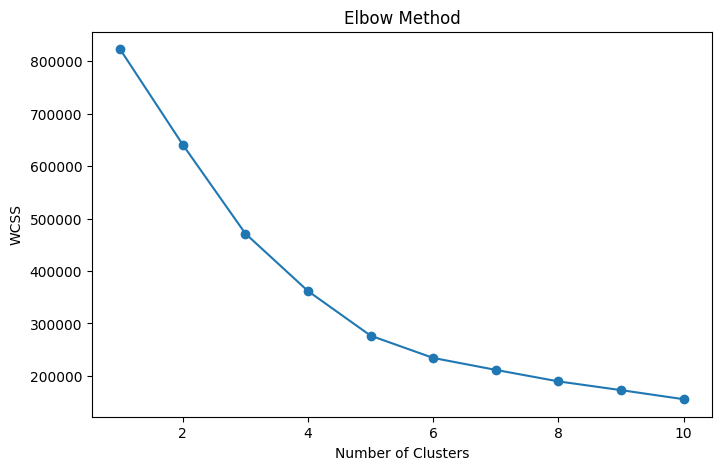

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

- The Elbow Method indicates a noticeable bend around **k = 5**.
- Beyond five clusters, the reduction in WCSS becomes gradual, suggesting diminishing returns from adding more clusters.
- Therefore, **5 clusters** were selected as the optimal number for K-Means clustering.

## **K-MEANS CLUSTERING**

**Applying the K-Means clustering algorithm with the optimal number of clusters obtained from the Elbow Method.**

In [ ]:
k = 5

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,21788
1,64232
2,1331
3,61755
4,56581


### Cluster Interpretation

**Cluster 0**
- Senior professionals
- Highest average experience
- Above-average salaries
- Suitable for leadership roles

**Cluster 1**
- Mid-level professionals
- Average salary around 12 LPA
- Largest learner segment

**Cluster 2**
- Very high salary outliers
- Smallest cluster
- Executive-level compensation

**Cluster 3**
- Mid-career professionals
- Balanced experience and salary

**Cluster 4**
- Early-career learners
- Lower experience
- Moderate salary

In [ ]:
cluster_summary = (
    df.groupby('Cluster')
      .agg(
          Avg_CTC=('ctc','mean'),
          Median_CTC=('ctc','median'),
          Avg_Experience=('Years_of_Experience','mean'),
          Learners=('email_hash','count')
      )
)

cluster_summary

,Avg_CTC,Median_CTC,Avg_Experience,Learners
Cluster,,,,
0,2.377709e+06,1950000.0,19.832890,21788
1,1.224090e+06,800000.0,9.817287,64232
2,1.353327e+08,100000000.0,10.520661,1331
3,1.442336e+06,1000000.0,10.188001,61755
4,1.192388e+06,800000.0,9.407381,56581


- The K-Means algorithm partitioned the learners into **5 distinct clusters**.
- The clusters vary considerably in size, indicating differences in the distribution of learner profiles.
- Cluster **2** contains the fewest learners but has the highest average CTC, suggesting that it captures a small group of exceptionally high-paid professionals.
- The remaining clusters represent learners with comparatively lower average CTC and varying levels of work experience.
- These clusters can be used to segment learners for personalized career guidance, salary benchmarking, and targeted upskilling recommendations.

## **HIERARCHICAL CLUSTERING**

**Hierarchical clustering was performed on a random sample of the standardized dataset to visualize the hierarchical relationships among learners.**

In [ ]:
sample = (
    pd.DataFrame(
        X_scaled,
        columns=features
    )
    .sample(2000, random_state=42)
)

In [ ]:
from scipy.cluster.hierarchy import linkage

linked = linkage(
    sample,
    method='ward'
)

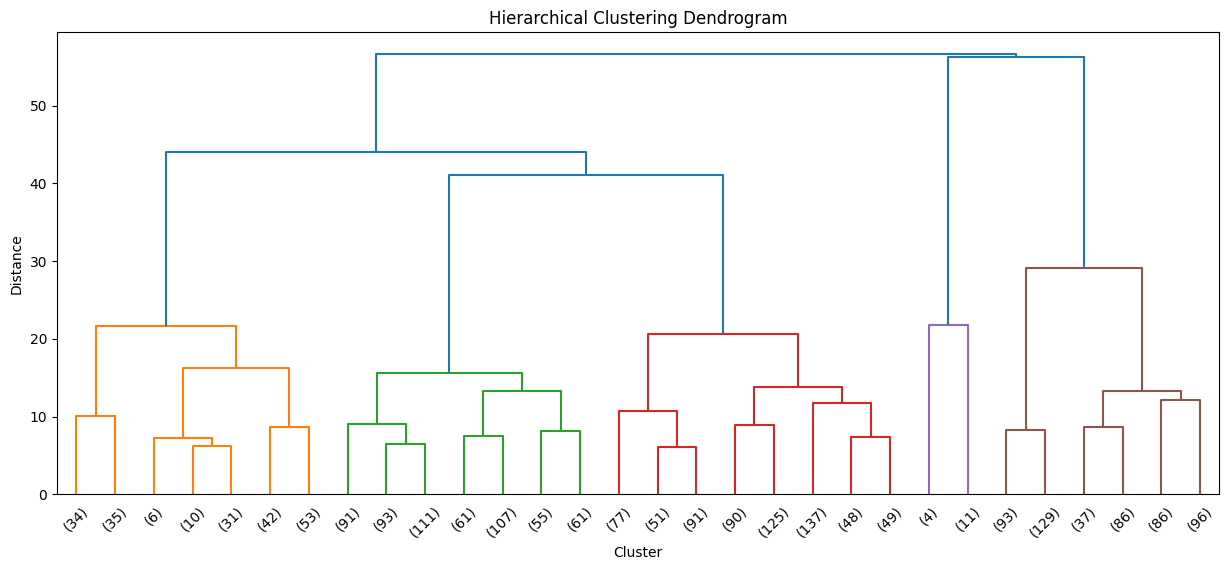

In [ ]:
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(15,6))

dendrogram(
    linked,
    truncate_mode='lastp',
    p=30
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster")
plt.ylabel("Distance")

plt.show()

- Hierarchical clustering was performed using **Ward's linkage** on a random sample of the standardized dataset.
- The dendrogram shows the presence of several distinct groups that merge at different linkage distances, indicating a hierarchical structure in the data.
- Larger vertical distances before cluster merges suggest that some learner groups are well separated from others.
- The dendrogram supports the use of clustering techniques and is consistent with the K-Means analysis performed earlier.

## **LIMITATIONS**

- Company names and employee identities are anonymized using hashes.
- Some peer groups contain only one employee, making the peer average equal to the employee's own salary.
- Extremely high CTC values may represent executive compensation or data-entry anomalies.
- Missing job positions may slightly affect department-level analyses.

# **ACTIONABLE INSIGHTS AND RECOMMENDATIONS**

1. **Peer-based salary benchmarking provides more meaningful compensation analysis.**  
   Comparing employees within the same company, job role, and years of experience (Designation flag) produces a fairer salary benchmark than comparing employees across the entire organization.

2. **Company-level benchmarking helps identify compensation leaders.**  
   The Tier classification distinguishes employees earning above or below their company's average salary, enabling organizations to recognize high performers and identify employees who may require compensation review.

3. **Department-level comparisons reveal salary disparities.**  
   The Class flag highlights employees earning above or below the average salary within the same company and job position, helping identify departments with comparatively higher or lower compensation.

4. **Mid-career professionals (5–7 years of experience) form an important talent segment.**  
   Employees with 5–7 years of experience who earn above their peer-group average demonstrate strong career progression and can serve as useful salary benchmarks for similar professionals.

5. **Top-paying companies can be identified using compensation data.**  
   Ranking companies based on average CTC enables Scaler to recommend organizations that consistently offer competitive salaries to learners seeking better career opportunities.

6. **Compensation varies significantly across similar job roles.**  
   The analysis of Data Science professionals indicates that salaries differ considerably across companies, emphasizing the importance of employer selection and career specialization.

7. **The dataset exhibits strong clustering characteristics.**  
   A Hopkins Statistic of **0.999** confirms that the learner data has a very strong clustering tendency, making it well-suited for unsupervised learning techniques.

8. **K-Means successfully segments learners into distinct career groups.**  
   Using the Elbow Method, five clusters were identified, representing different learner segments based on compensation and work experience.

9. **Hierarchical clustering supports the K-Means results.**  
   The dendrogram indicates the presence of well-separated learner groups, validating the segmentation obtained through K-Means clustering.

10. **Data preprocessing improved the reliability of the analysis.**  
    Handling missing values, removing unrealistic experience values, engineering new features, encoding categorical variables, and standardizing numerical features contributed to more reliable clustering and business insights.

---

## **Business Recommendations**

- Adopt **peer-group salary benchmarking** (Company + Job Position + Years of Experience) for fair and meaningful compensation comparisons.
- Recommend **high-paying companies** to learners based on historical salary trends identified through the analysis.
- Use the **Designation, Class, and Tier** flags to identify employees who may benefit from salary revisions, promotions, or targeted career development.
- Leverage **cluster-based segmentation** to personalize learning paths, career guidance, mentorship, and placement recommendations.
- Encourage learners to benchmark salaries using **both average and median CTC**, especially in the presence of salary outliers.
- Continuously monitor salary trends across companies and job roles to provide updated career insights and industry benchmarks.
- Identify companies with consistently competitive compensation across multiple roles for stronger placement partnerships.
- Use clustering insights to group learners with similar profiles and deliver more personalized recommendations for courses, interview preparation, and job opportunities.

---

## **Conclusion**

- This study combined **Exploratory Data Analysis, Feature Engineering, Manual Clustering, and Unsupervised Learning** to analyze compensation patterns across companies, job roles, and experience levels.

- The manually created **Designation, Class, and Tier** flags enabled meaningful peer-based salary benchmarking, while **K-Means** and **Hierarchical Clustering** identified natural learner segments based on compensation and work experience.

- Overall, the analysis provides valuable insights that can help **Scaler** improve learner profiling, recommend suitable employers, personalize career guidance, benchmark salaries, and support data-driven decision-making for both learners and partner organizations.These findings can support Scaler in improving salary benchmarking, learner segmentation, personalized career guidance, and strategic placement partnerships.